## Visualize Mask

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from matplotlib.colors import ListedColormap, BoundaryNorm

from pkg.mask.generate_mask import create_feature_mask

In [2]:
input_path = "../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
climatology_path = "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"

input_ds = xr.open_dataset(input_path)
climatology_ds = xr.open_dataset(climatology_path)

In [3]:
def plot_10m_wind_speed(prediction: xr.Dataset, title: str = "10m Wind Speed over Europe"):
    """
    Plots the 10m wind speed at 22:00 UTC from a prediction dataset over Europe.

    Parameters
    ----------
    prediction : xr.Dataset
        An xarray Dataset containing 10m_u_component_of_wind and 10m_v_component_of_wind variables.
    """
    # Compute 10m wind speed
    u10 = prediction["10m_u_component_of_wind"]
    v10 = prediction["10m_v_component_of_wind"]
    wind_speed = np.sqrt(u10**2 + v10**2)

    # Select time closest to 22:00 UTC on 2022-02-18
    selected_time = np.datetime64("2022-02-18T22:00")
    wind = wind_speed.sel(time=selected_time, method="nearest")

    # Plot setup
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    # ax.set_extent([-25, 45, 30, 72], crs=ccrs.PlateCarree())  # Europe extent
    ax.set_extent([-80, 30, 30, 70], crs=ccrs.PlateCarree())  # Atlantic-Europe Region

    # Plot wind speed
    wind.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=0,
        vmax=30,
        cbar_kwargs={"label": "10m wind speed (m/s)"}
    )

    # Add map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.set_title(title)

    plt.show()

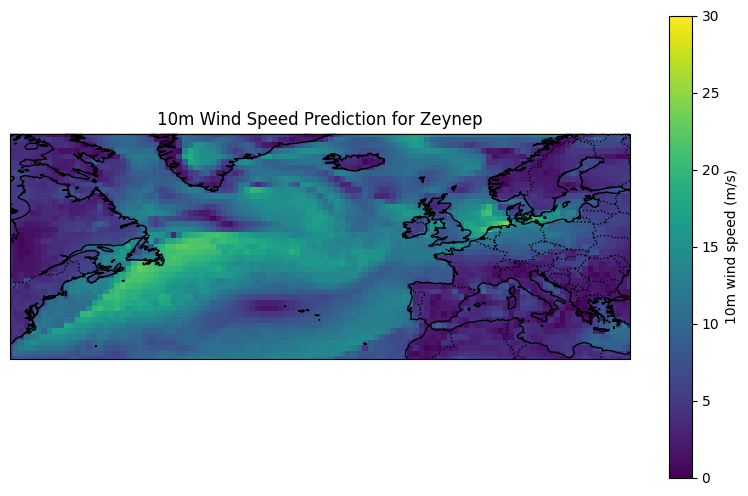

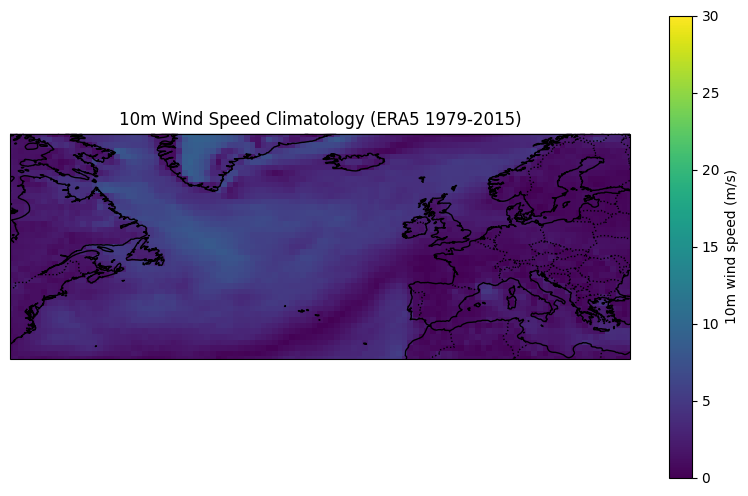

In [ ]:
plot_10m_wind_speed(input_ds, title="10m Wind Speed Prediction for Zeynep")
plot_10m_wind_speed(climatology_ds, title="10m Wind Speed Climatology (ERA5 1979-2015)")

In [3]:
mask_storm_core = create_feature_mask(input_ds, regions=["storm_core_10utc", "storm_core_16utc"])
mask_jet_stream = create_feature_mask(input_ds, regions=["dynamic_uljs"])

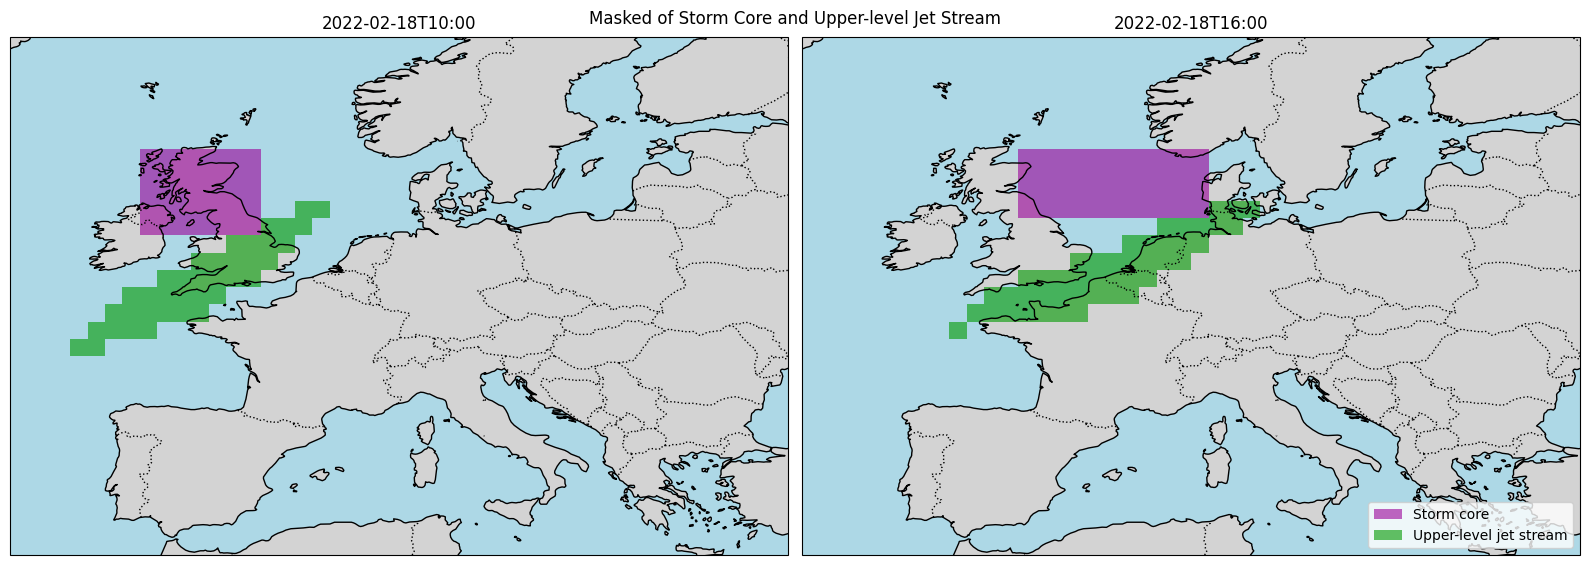

In [5]:
masked_var = "u_component_of_wind"
level_index = 7        # 300 hPa
time_indices = [0, 1]  # t=10:00, t=16:00

# Prepare a 4‐color map: 
#   0→transparent, 1→purple, 2→green, 3→black
cmap = ListedColormap([
    (0,0,0,0),      # 0 = nothing (transparent)
    (0.6, 0, 0.6, 0.6),  # 1 = storm core (semi‐opaque purple)
    (0, 0.6, 0, 0.6),    # 2 = jet stream (semi‐opaque green)
    (0, 0, 0, 0.8),      # 3 = overlap (mostly opaque black)
])
norm = BoundaryNorm([0,1,2,3,4], cmap.N)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16,6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, t_idx in zip(axes, time_indices):
    # extract the two mask layers at this time+level
    storm = mask_storm_core[masked_var] \
                .isel(time=t_idx, level=level_index) \
                .squeeze("batch") \
                .values.astype(int)
    jet   = mask_jet_stream[masked_var] \
                .isel(time=t_idx, level=level_index) \
                .squeeze("batch") \
                .values.astype(int)

    # combined code: 0,1,2,3
    combined = storm + 2*jet

    # plot
    mesh = ax.pcolormesh(
        mask_storm_core.lon, mask_storm_core.lat, combined,
        cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree()
    )

    # add coast/borders/land/ocean
    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.LAND,   facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN,  facecolor="lightblue")

    # zoom
    ax.set_extent([-15,30,35,65], ccrs.PlateCarree())
    ax.set_title(f"{str(mask_storm_core.time.values[t_idx])[:16]}")

# build a little legend
from matplotlib.patches import Patch
legend_patches = [
    Patch(facecolor=cmap(1), label="Storm core"),
    Patch(facecolor=cmap(2), label="Upper-level jet stream"),
]
axes[1].legend(handles=legend_patches, loc="lower right")

plt.suptitle("Masked of Storm Core and Upper-level Jet Stream", y=0.95)
plt.tight_layout()
plt.show()
